In [ ]:
# Menghubungkan Google Colab dengan Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Impor library yang dibutuhkan
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import matplotlib.pyplot as plt
import numpy as np

Mounted at /content/drive


In [ ]:

train_dir = '/content/drive/MyDrive/Dataset_sampah/Training'
validation_dir = '/content/drive/MyDrive/Dataset_sampah/Validation'


# Tentukan parameter untuk gambar dan batch
IMG_SIZE = (224, 224) # Ukuran gambar yang direkomendasikan untuk MobileNetV2
BATCH_SIZE = 32

# Gunakan ImageDataGenerator untuk memuat data dan melakukan augmentasi
# Kita gunakan preprocessing_function khusus untuk MobileNetV2
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

# Buat generator data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary' # Untuk 2 kelas (organik/anorganik)
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 1194 images belonging to 2 classes.
Found 276 images belonging to 2 classes.


In [ ]:
# 1. Muat model dasar MobileNetV2 (tanpa lapisan klasifikasi di atasnya)
# `include_top=False` berarti kita tidak menyertakan lapisan output asli dari model
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet' # Gunakan bobot yang sudah dilatih pada dataset ImageNet
)

# 2. Bekukan (freeze) lapisan-lapisan di model dasar
# Ini agar bobot yang sudah terlatih tidak berubah saat training awal
base_model.trainable = False

# 3. Tambahkan lapisan klasifikasi kita sendiri di atas model dasar
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x) # Meratakan output menjadi vektor
x = Dropout(0.2)(x) # Tambahkan dropout untuk regularisasi
outputs = Dense(1, activation='sigmoid')(x) # Lapisan output untuk 2 kelas

# 4. Gabungkan menjadi model akhir
model = Model(inputs, outputs)

# Tampilkan ringkasan model
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Kompilasi model dengan optimizer, loss function, dan metrik
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Tentukan jumlah epoch
# Dengan transfer learning, seringkali tidak butuh epoch sebanyak melatih dari nol
EPOCHS = 5

# Mulai proses training
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 758s 20s/step - accuracy: 0.6514 - loss: 0.6204 - val_accuracy: 0.7609 - val_loss: 0.4950
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 274s 7s/step - accuracy: 0.7673 - loss: 0.5074 - val_accuracy: 0.8768 - val_loss: 0.4013
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 257s 7s/step - accuracy: 0.8444 - loss: 0.4119 - val_accuracy: 0.9384 - val_loss: 0.3296
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 244s 6s/step - accuracy: 0.9150 - loss: 0.3177 - val_accuracy: 0.9638 - val_loss: 0.2791
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 240s 6s/step - accuracy: 0.9280 - loss: 0.2796 - val_accuracy: 0.9710 - val_loss: 0.2430


9/9 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step
Classification Report
              precision    recall  f1-score   support

   Anorganik       0.96      0.98      0.97       139
     Organik       0.98      0.96      0.97       137

    accuracy                           0.97       276
   macro avg       0.97      0.97      0.97       276
weighted avg       0.97      0.97      0.97       276

Confusion Matrix


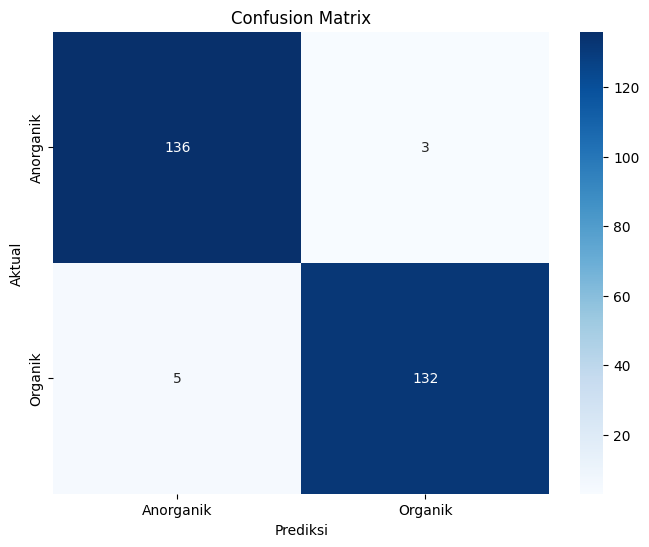

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Membuat prediksi pada seluruh data validasi
# Pastikan validation_generator di-reset dan tidak di-shuffle
validation_generator.reset()
Y_pred = model.predict(validation_generator, steps=validation_generator.samples // BATCH_SIZE + 1)
y_pred = (Y_pred > 0.5).astype(int) # Konversi probabilitas menjadi kelas biner (0 atau 1)

# 2. Mendapatkan label yang sebenarnya
y_true = validation_generator.classes

# 3. Menampilkan Classification Report (Akurasi, Presisi, Recall, F1-Score)
print("Classification Report")
# Urutan kelas: 'anorganik' (kelas 0), 'organik' (kelas 1)
target_names = list(validation_generator.class_indices.keys())
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Menampilkan Confusion Matrix
print("Confusion Matrix")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()


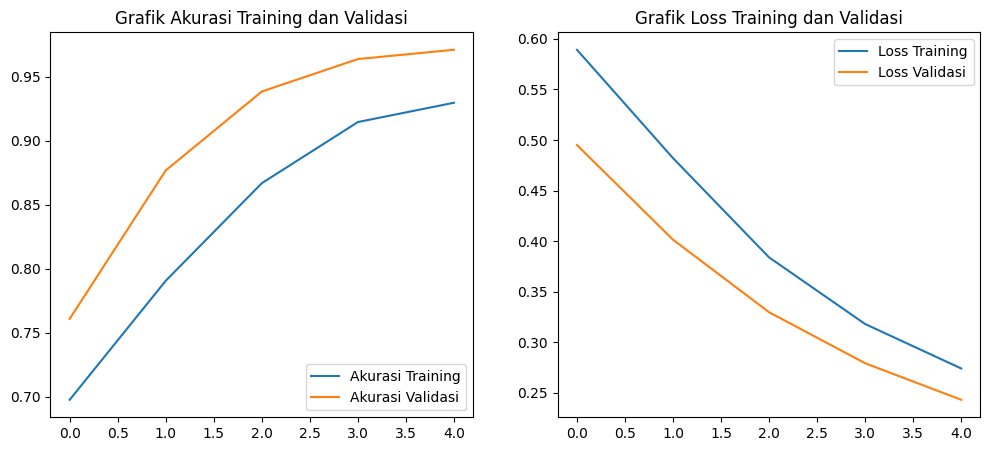

In [ ]:
# Ambil hasil dari history training
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

# Buat plot untuk akurasi
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Akurasi Training')
plt.plot(epochs_range, val_acc, label='Akurasi Validasi')
plt.legend(loc='lower right')
plt.title('Grafik Akurasi Training dan Validasi')

# Buat plot untuk loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss Training')
plt.plot(epochs_range, val_loss, label='Loss Validasi')
plt.legend(loc='upper right')
plt.title('Grafik Loss Training dan Validasi')
plt.show()

Saving download (15).jpeg to download (15) (3).jpeg


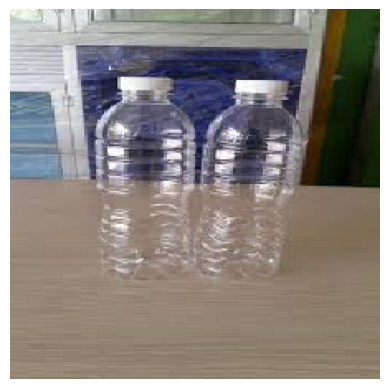

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
File: download (15) (3).jpeg
Prediksi: Sampah Anorganik


In [ ]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Upload gambar baru
uploaded = files.upload()

for fn in uploaded.keys():
  # Memuat dan mempersiapkan gambar
  path = fn
  img = image.load_img(path, target_size=(224, 224))
  plt.imshow(img)
  plt.axis('Off')
  plt.show()

  # Konversi gambar ke array dan lakukan preprocessing
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

  # Lakukan prediksi
  images = np.vstack([x])
  classes = model.predict(images, batch_size=10)

  print(f"File: {fn}")

  # Cek hasil prediksi (kelas 0 atau 1)
  # Catatan: Urutan kelas (0=anorganik, 1=organik) ditentukan oleh abjad nama folder
  # 'anorganik' (a) akan menjadi kelas 0, 'organik' (o) akan menjadi kelas 1
  if classes[0] < 0.5:
    print('Prediksi: Sampah Anorganik')
  else:
    print('Prediksi: Sampah Organik')

In [ ]:
model.save('model_sampah_mobilenetv2.h5')